# 📊 Proyecto de Análisis de Compras en E-commerce

## Contexto del Dataset
Este dataset simula las transacciones realizadas en una plataforma de e-commerce.  
Cada registro representa una compra realizada por un cliente, incluyendo información sobre el producto, el precio, el descuento aplicado, el método de pago y la fecha de la transacción.

### Columnas del Dataset
- **User_ID**: Identificador único del cliente.
- **Product_ID**: Identificador único del producto comprado.
- **Category**: Categoría del producto (ejemplo: Sports, Electronics, Fashion).
- **Price**: Precio original del producto antes del descuento.
- **Discount**: Porcentaje de descuento aplicado a la compra.
- **Final_Price**: Precio final pagado por el cliente después del descuento.
- **Payment_Method**: Método de pago utilizado (ejemplo: Net Banking, Credit Card, UPI).
- **Purchase_Date**: Fecha en la que se realizó la compra.

### Objetivo del Proyecto
El propósito de este dataset es practicar habilidades de **Data Analyst** y **Data Scientist**:
- **SQL**: creación de tablas, limpieza de datos, consultas para KPIs (ventas totales, descuentos promedio, métodos de pago más usados).
- **Python**: carga del dataset, transformación y análisis exploratorio con Pandas.
- **Power BI**: construcción de un dashboard interactivo para visualizar métricas clave como:
  - Ventas por categoría.
  - Evolución de ventas en el tiempo.
  - Métodos de pago más utilizados.
  - Impacto de los descuentos en las ventas.

### Escenario de Negocio
La empresa busca responder preguntas como:
- ¿Qué categorías generan más ingresos?
- ¿Cuál es el método de pago preferido por los clientes?
- ¿Qué nivel de descuento impulsa más las ventas?
- ¿Cómo evolucionan las compras a lo largo del tiempo?

Este proyecto permite simular un flujo completo de análisis de datos:  
**Dataset → SQL/Python → Dashboard en Power BI → Insights de negocio.**

---------

## **Creacion de base de datos**

In [1]:
# Importar sqlite3
import sqlite3

# Conectar con el archivo ecommerce.db si no existe lo crea
conn = sqlite3.connect("ecommerce.db")

# Crear el cursor
cursor = conn.cursor()

# Crear la tabla
cursor.execute("""
CREATE TABLE IF NOT EXISTS compras (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    User_ID TEXT,
    Product_ID TEXT,
    Category TEXT,
    Price REAL,
    Discount REAL,
    Final_Price REAL,
    Payment_Method TEXT,
    Purchase_Date TEXT
);
""")

# Ejecutar con el commit
conn.commit()


---
## **Cargamos el dataset en la base de datos**

In [2]:
import pandas as pd
import sqlite3

# Leer CSV
df = pd.read_csv("../data/ecommerce_dataset_clean.csv")

# Conectar a la base
conn = sqlite3.connect("ecommerce.db")

# Insertar datos
df.to_sql("compras", conn, if_exists="append", index=False)



3660

---
# **KPIs:**

----
## Ventas por categoria

In [3]:
query = """
SELECT Category, SUM(Final_Price) as Total_Ventas
FROM compras
GROUP BY Category
ORDER BY Total_Ventas DESC
"""
ventas_categoria=pd.read_sql_query(query, conn)
print("Ventas por categoría:\n", ventas_categoria)


Ventas por categoría:
          Category  Total_Ventas
0        Clothing     115314.84
1           Books     111149.35
2  Home & Kitchen     110328.08
3          Sports     108518.79
4            Toys     107289.69
5          Beauty     104215.10
6     Electronics     100462.23


--------
## Metodo de pago mas utilizado

In [4]:
query2 = """
SELECT Payment_Method, COUNT(*) AS cantidad_transacciones
FROM compras
GROUP BY Payment_Method
ORDER BY cantidad_transacciones DESC;
"""
metodos_pago = pd.read_sql_query(query2, conn)
print("\nMétodos de pago más usados:\n", metodos_pago)


Métodos de pago más usados:
      Payment_Method  cantidad_transacciones
0       Credit Card                     760
1               Upi                     757
2        Debit Card                     731
3       Net Banking                     716
4  Cash On Delivery                     696


----
## Descuento promedio por categoria

In [5]:
query3 = """
SELECT Category, AVG(Discount) AS descuento_promedio
FROM compras
GROUP BY Category
ORDER BY descuento_promedio DESC;
"""
descuentos = pd.read_sql_query(query3, conn)
print("\nDescuento promedio por categoría:\n", descuentos)


Descuento promedio por categoría:
          Category  descuento_promedio
0  Home & Kitchen           19.608379
1          Sports           19.326923
2     Electronics           19.267068
3           Books           19.035581
4          Beauty           18.475248
5            Toys           18.126195
6        Clothing           17.919021


----
## Evolucion mensual de ventas

In [6]:
query4 = """
SELECT strftime('%Y-%m', Purchase_Date) AS mes,
       SUM(Final_Price) AS ventas_mensuales
FROM compras
GROUP BY mes
ORDER BY mes;
"""
ventas_mensuales = pd.read_sql_query(query4, conn)
print("\nVentas mensuales:\n", ventas_mensuales)


Ventas mensuales:
         mes  ventas_mensuales
0   2024-01          69009.43
1   2024-02          69186.34
2   2024-03          71325.40
3   2024-04          74365.13
4   2024-05          68837.25
5   2024-06          64256.66
6   2024-07          72798.23
7   2024-08          71506.96
8   2024-09          68043.09
9   2024-10          76034.51
10  2024-11          51915.08


-----
## Top 10 productos mas vendidos


In [7]:
query5 = """
SELECT Product_ID, COUNT(*) AS cantidad_vendida,
       SUM(Final_Price) AS ingresos
FROM compras
GROUP BY Product_ID
ORDER BY cantidad_vendida DESC
LIMIT 10;
"""
top_productos = pd.read_sql_query(query5, conn)
print("\nTop 10 productos más vendidos:\n", top_productos)


Top 10 productos más vendidos:
    Product_ID  cantidad_vendida  ingresos
0  ffc76feb-5                 1    125.70
1  ffb9c83c-f                 1    355.36
2  ffa4a462-b                 1    356.13
3  ff781f26-c                 1    259.10
4  ff777544-d                 1    350.73
5  ff1218f2-a                 1    357.63
6  fefd3d88-4                 1    338.11
7  feeeabdc-c                 1    161.60
8  fe974b83-c                 1     86.46
9  fe92f8a3-b                 1    199.91


-----
## Ticket promedio por cliente

In [8]:
query6 = """
SELECT User_ID, AVG(Final_Price) AS ticket_promedio,
       SUM(Final_Price) AS total_gastado
FROM compras
GROUP BY User_ID
ORDER BY total_gastado DESC;
"""
ticket_cliente = pd.read_sql_query(query6, conn)
print("\nTicket promedio por cliente:\n", ticket_cliente)


Ticket promedio por cliente:
        User_ID  ticket_promedio  total_gastado
0     8b885340           496.82         496.82
1     20797b76           495.02         495.02
2     d8970dd2           493.04         493.04
3     da7bc76a           492.41         492.41
4     68722b9b           491.70         491.70
...        ...              ...            ...
3655  480c40b5             7.69           7.69
3656  526f0441             7.49           7.49
3657  ee84c4d8             7.33           7.33
3658  2d3fc0c1             6.35           6.35
3659  caba820c             5.89           5.89

[3660 rows x 3 columns]


-----
# **Graficos KPIs**

----
## Ventas por categoria (Bart chart)

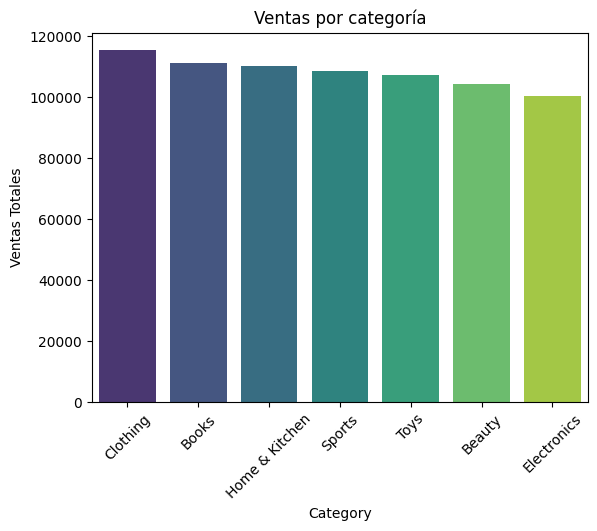

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=ventas_categoria, x="Category", y="Total_Ventas", palette="viridis")
plt.title("Ventas por categoría")
plt.xticks(rotation=45)
plt.ylabel("Ventas Totales")
plt.show()


👉 Muestra qué categorías generan más ingresos.

----
## Metodo de pago mas utilizado (Pie chart)

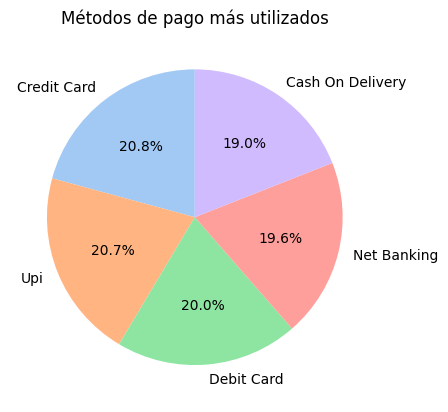

In [10]:
plt.pie(metodos_pago["cantidad_transacciones"], 
        labels=metodos_pago["Payment_Method"], 
        autopct="%1.1f%%", 
        startangle=90, 
        colors=sns.color_palette("pastel"))
plt.title("Métodos de pago más utilizados")
plt.show()


👉 Visualiza la proporción de cada método de pago.

---
## Descuento promedio por categoría (Horizontal bar chart)


C:\Users\Benja\AppData\Local\Temp\ipykernel_23968\2411627029.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=descuentos, x="descuento_promedio", y="Category", palette="magma")


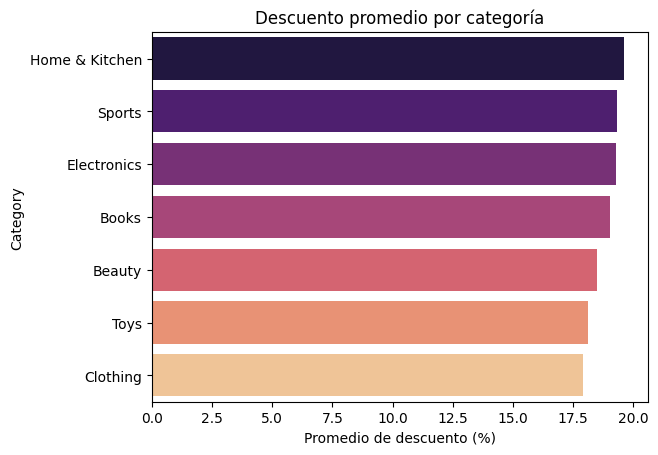

In [11]:
sns.barplot(data=descuentos, x="descuento_promedio", y="Category", palette="magma")
plt.title("Descuento promedio por categoría")
plt.xlabel("Promedio de descuento (%)")
plt.show()


👉 Compara qué categorías tienen mayores descuentos.

-----
## Evolución mensual de ventas (Line chart)

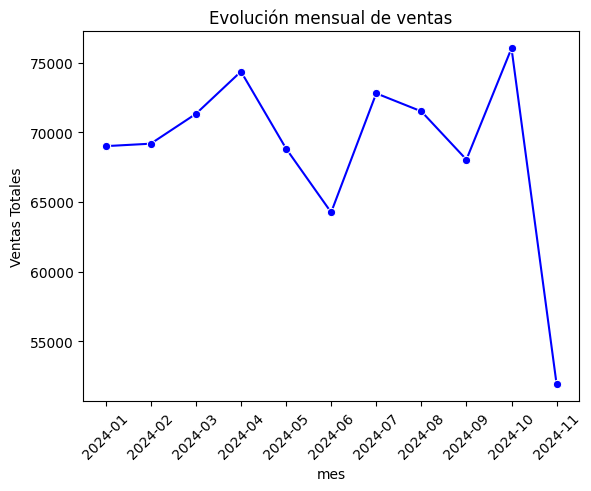

In [12]:
sns.lineplot(data=ventas_mensuales, x="mes", y="ventas_mensuales", marker="o", color="blue")
plt.title("Evolución mensual de ventas")
plt.xticks(rotation=45)
plt.ylabel("Ventas Totales")
plt.show()


👉 Muestra cómo cambian las ventas a lo largo del tiempo.

-----
## Top 10 productos más vendidos (Bar chart)

C:\Users\Benja\AppData\Local\Temp\ipykernel_23968\3437040719.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_productos, x="cantidad_vendida", y="Product_ID", palette="cubehelix")


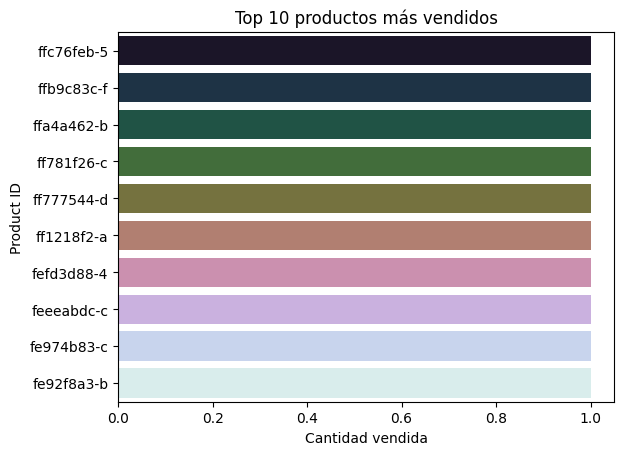

In [13]:
sns.barplot(data=top_productos, x="cantidad_vendida", y="Product_ID", palette="cubehelix")
plt.title("Top 10 productos más vendidos")
plt.xlabel("Cantidad vendida")
plt.ylabel("Product ID")
plt.show()


👉 Ranking de productos más populares.

----
## Ticket promedio por cliente (Histogram)

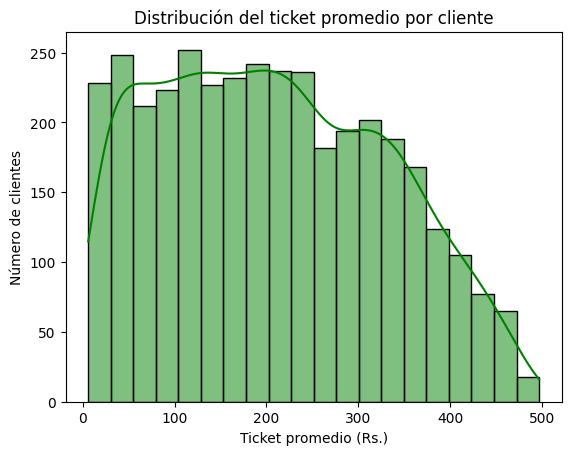

In [14]:
sns.histplot(ticket_cliente["ticket_promedio"], bins=20, kde=True, color="green")
plt.title("Distribución del ticket promedio por cliente")
plt.xlabel("Ticket promedio (Rs.)")
plt.ylabel("Número de clientes")
plt.show()


👉 Analiza cómo se distribuye el gasto promedio entre clientes.